In [1]:
!pip install -q transformers datasets evaluate accelerate sentencepiece nltk scikit-learn rouge_score bert_score sacrebleu


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [2]:
import json
import re
import torch
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer, 
    AutoModelForSeq2SeqLM, 
    Seq2SeqTrainingArguments, 
    Seq2SeqTrainer,
    DataCollatorForSeq2Seq
)
import evaluate
from sklearn.metrics import accuracy_score, f1_score, classification_report

nltk.download("punkt")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [3]:
# 1. EXPANDED COLOR DICTIONARY (Fixes the "Green -> Gray" blindspot)
COLORS = {
    "black": (0, 0, 0), "white": (255, 255, 255), "red": (255, 0, 0),
    "lime": (0, 255, 0), "blue": (0, 0, 255), "yellow": (255, 255, 0),
    "cyan": (0, 255, 255), "magenta": (255, 0, 255), "silver": (192, 192, 192),
    "gray": (128, 128, 128), "maroon": (128, 0, 0), "olive": (128, 128, 0),
    "green": (0, 128, 0), "purple": (128, 0, 128), "teal": (0, 128, 128),
    "navy": (0, 0, 128), "darkblue": (0, 0, 139), "lightblue": (173, 216, 230),
    "orange": (255, 165, 0), "pink": (255, 192, 203), "brown": (165, 42, 42),
}

def get_closest_color_name(hex_code):
    try:
        hex_code = hex_code.lstrip('#')
        if len(hex_code) == 3: hex_code = ''.join([c*2 for c in hex_code])
        rgb = tuple(int(hex_code[i:i+2], 16) for i in (0, 2, 4))
        return min(COLORS.keys(), key=lambda n: sum((c1-c2)**2 for c1,c2 in zip(rgb, COLORS[n])))
    except: return hex_code

def clean_colors(text):
    hex_pattern = re.compile(r'#[0-9a-fA-F]{3,6}\b')
    return hex_pattern.sub(lambda m: get_closest_color_name(m.group(0)), text)

def compact_markdown(text):
    lines = text.split('\n')
    compacted = [line.replace('|', ' ').strip() for line in lines if '| :---' not in line and line.strip()]
    return " ; ".join(compacted)

In [4]:
def load_and_format_data(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
        
    formatted = {"input_text": [], "target_text": []}
    
    for item in data:
        clean_md = clean_colors(item.get("enriched_markdown", ""))
        # Compact the markdown to save tokens
        lines = clean_md.split('\n')
        compact_md = " ; ".join([l.replace('|', ' ').strip() for l in lines if '| :---' not in l and l.strip()])
        
        claim = item.get("claim", "")
        title = " ".join(str(item.get("title_description", "")).split()[:50])
        label = "SUPPORTED" if item.get("label") == True else "REFUTED"
        explanation = item.get("explanation", "")
        
        # New Input: Explicitly request reasoning
        input_text = f"Analyze the chart to verify the claim. | Claim: {claim} | Title: {title} | Context: {compact_md}"
        # New Output: Explanation FIRST, Label SECOND
        target_text = f"Explanation: {explanation} Label: {label}."
        
        formatted["input_text"].append(input_text)
        formatted["target_text"].append(target_text)
        
    return Dataset.from_dict(formatted)

# Load all splits
dataset = DatasetDict({
    "train": load_and_format_data("train_w_spec.json"),
    "validation": load_and_format_data("validation_w_spec.json"),
    "test_1": load_and_format_data("test_1_w_spec.json"),
    "test_2": load_and_format_data("test_2_w_spec.json")
})

Token indices sequence length is longer than the specified maximum sequence length for this model (553 > 512). Running this sequence through the model will result in indexing errors


Analyzing token lengths (this may take a minute)...

--- Token Length Percentiles ---
           tokens
count  981.000000
mean   197.362895
std     82.354317
min     89.000000
50%    179.000000
75%    224.000000
90%    289.000000
95%    333.000000
99%    553.000000
max    582.000000


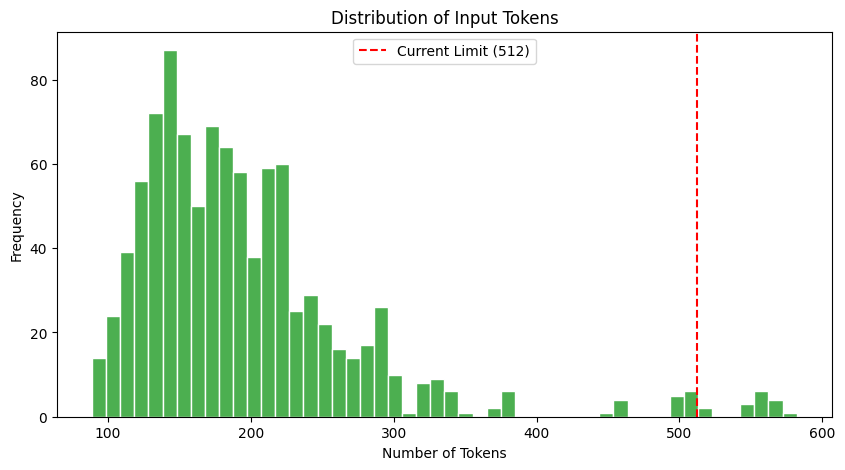

In [4]:
# # 1. Initialize tokenizer for analysis
# model_id = "google/flan-t5-large"
# tokenizer = AutoTokenizer.from_pretrained(model_id)

# def check_token_distribution(dataset_split):
#     lengths = []
#     print("Analyzing token lengths (this may take a minute)...")
    
#     for item in dataset_split:
#         # Measure length WITHOUT truncation
#         tokens = tokenizer.encode(item['input_text'], add_special_tokens=True)
#         lengths.append(len(tokens))
    
#     df_len = pd.DataFrame(lengths, columns=['tokens'])
    
#     # 2. Display Statistics
#     print("\n--- Token Length Percentiles ---")
#     print(df_len.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))
    
#     # 3. Visualize
#     plt.figure(figsize=(10, 5))
#     plt.hist(lengths, bins=50, color='#4CAF50', edgecolor='white')
#     plt.axvline(512, color='red', linestyle='--', label='Current Limit (512)')
#     plt.title('Distribution of Input Tokens')
#     plt.xlabel('Number of Tokens')
#     plt.ylabel('Frequency')
#     plt.legend()
#     plt.show()

# # Run the check on your training set
# check_token_distribution(dataset['test_2'])

In [5]:
model_id = "google/flan-t5-large"
tokenizer = AutoTokenizer.from_pretrained(model_id)

def tokenize_fn(examples):
    model_inputs = tokenizer(examples["input_text"], max_length=512, truncation=True, padding="max_length")
    labels = tokenizer(examples["target_text"], max_length=256, truncation=True, padding="max_length")
    model_inputs["labels"] = [[(l if l != tokenizer.pad_token_id else -100) for l in label] for label in labels["input_ids"]]
    return model_inputs

tokenized_datasets = dataset.map(tokenize_fn, batched=True, remove_columns=["input_text", "target_text"])

config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/7607 [00:00<?, ? examples/s]

Map:   0%|          | 0/953 [00:00<?, ? examples/s]

Map:   0%|          | 0/939 [00:00<?, ? examples/s]

Map:   0%|          | 0/981 [00:00<?, ? examples/s]

In [6]:
model = AutoModelForSeq2SeqLM.from_pretrained(model_id)
# Fix for T5 memory optimization
if hasattr(model, "gradient_checkpointing_enable"):
    model.gradient_checkpointing_enable()

training_args = Seq2SeqTrainingArguments(
    output_dir="./results",
    
    # --- STEP-BASED EVALUATION ---
    eval_strategy="steps",       # Evaluate by steps instead of epochs
    eval_steps=50,               # Run validation every 50 steps
    logging_strategy="steps",    # Print training loss every 50 steps
    logging_steps=50,
    save_strategy="steps",       # Save a checkpoint every 50 steps
    save_steps=50,
    load_best_model_at_end=True, # Automatically load the best step-checkpoint at the end
    # -----------------------------
    
    learning_rate=3e-5,
    
    # --- STABILITY FIXES (Crucial for preventing NaN) ---
    bf16=True,                   # Keep this to prevent fp16 overflow
    max_grad_norm=1.0,           # Keep this to clip exploding gradients
    warmup_ratio=0.1,            # Keep this for safe learning rate scaling
    
    # --- MEMORY OPTIMIZATIONS ---
    per_device_train_batch_size=4,    
    gradient_accumulation_steps=4,     
    gradient_checkpointing=True,       
    optim="adafactor",                 

    generation_max_length=256,
    per_device_eval_batch_size=2,
    weight_decay=0.01,
    num_train_epochs=3,
    predict_with_generate=True,
    save_total_limit=2,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    processing_class=tokenizer,
    data_collator=DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model),
)

trainer.train()

model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
/usr/local/lib/python3.11/dist-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


TrainOutput(global_step=1428, training_loss=5.592843170593433, metrics={'train_runtime': 4814.6224, 'train_samples_per_second': 4.74, 'train_steps_per_second': 0.297, 'total_flos': 5.259710940630221e+16, 'train_loss': 5.592843170593433, 'epoch': 3.0})

In [7]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, classification_report
import evaluate

# --- NEW HELPER FUNCTION (Chain-of-Thought Parser) ---
def parse_pred(pred):
    """
    Parses the new format: 'Explanation: ... Label: SUPPORTED.'
    """
    pred = pred.strip()
    label = "REFUTED" # Default fallback
    explanation = pred
    
    if "Label:" in pred:
        # Split the string at 'Label:'
        parts = pred.split("Label:")
        
        # Everything before 'Label:' is the explanation
        explanation = parts[0].replace("Explanation:", "").strip()
        
        # Everything after 'Label:' is the classification
        label_text = parts[-1].strip().upper()
        if "SUPPORTED" in label_text:
            label = "SUPPORTED"
        elif "REFUTED" in label_text:
            label = "REFUTED"
    else:
        # Fallback just in case the model forgets to output 'Label:'
        explanation = pred.replace("Explanation:", "").strip()
        
    return label, explanation
# -----------------------------------------------------

# Load metrics
rouge_metric = evaluate.load("rouge")
bleu_metric = evaluate.load("sacrebleu")
bert_metric = evaluate.load("bertscore")

def get_metrics(split_name):
    print(f"Evaluating {split_name}...")
    
    # 1. Run Prediction
    preds_output = trainer.predict(tokenized_datasets[split_name])
    
    # 2. Clean -100 from predictions and labels
    clean_pred_ids = np.where(preds_output.predictions != -100, preds_output.predictions, tokenizer.pad_token_id)
    clean_label_ids = np.where(preds_output.label_ids != -100, preds_output.label_ids, tokenizer.pad_token_id)
    
    # 3. Decode Predictions and Labels
    decoded_preds = tokenizer.batch_decode(clean_pred_ids, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(clean_label_ids, skip_special_tokens=True)

    # 4. Parse strings into clean Labels and Explanations using the NEW parser
    p_labels, p_expls = zip(*[parse_pred(p) for p in decoded_preds])
    t_labels, t_expls = zip(*[parse_pred(t) for t in decoded_labels])

    # 5. Calculate Classification Metrics
    acc = accuracy_score(t_labels, p_labels) * 100
    f1 = f1_score(t_labels, p_labels, average='macro') * 100
    
    # 6. Calculate NLG Metrics
    rouge_l = rouge_metric.compute(predictions=p_expls, references=t_expls)['rougeL'] * 100
    bleu = bleu_metric.compute(predictions=p_expls, references=[[t] for t in t_expls])['score']
    
    # BERTScore can take a moment, so we calculate it last
    print("Calculating BERTScore...")
    bert_score = bert_metric.compute(predictions=p_expls, references=t_expls, lang="en")
    avg_bert = np.mean(bert_score['f1']) * 100
    
    # 7. Create Detailed DataFrame and Save CSV
    results_df = pd.DataFrame({
        "input_text": dataset[split_name]["input_text"],
        "true_label": t_labels,
        "pred_label": p_labels,
        "true_explanation": t_expls,
        "pred_explanation": p_expls,
    })
    
    csv_name = f"results_{split_name}_CoT.csv"
    results_df.to_csv(csv_name, index=False)
    print(f"-> Detailed results saved to {csv_name}")
    
    return {
        "acc": acc, "f1": f1, "rouge": rouge_l, "bleu": bleu, "bert": avg_bert,
        "report": classification_report(t_labels, p_labels, digits=4)
    }

# Execute evaluations
# (Assuming your test datasets are loaded into tokenized_datasets["test_1"] etc.)
# If they are not tokenized yet, you will need to map them through tokenize_fn first.
res1 = get_metrics("test_1")
res2 = get_metrics("test_2")

# --- FINAL FORMATTED OUTPUT ---
print("\n" + "="*115)
print("  CHARTCHECK EVALUATION MATRIX — Chain-of-Thought Results")
print("="*115)

avg_acc = (res1['acc'] + res2['acc']) / 2
avg_bleu = (res1['bleu'] + res2['bleu']) / 2
avg_rouge = (res1['rouge'] + res2['rouge']) / 2
avg_bert = (res1['bert'] + res2['bert']) / 2

print(f"{'Model':>28} {'Task':>5} {'Test1_Acc':>9} {'Test1_F1':>9} {'Test2_Acc':>9} {'Test2_F1':>9} {'Avg_Acc':>8} {'BLEU':>6} {'ROUGE-L':>7} {'BERTScore':>9}")
print(f"{'Flan-T5-Large (CoT)':>28} {'M':>5} {res1['acc']:>9.1f} {res1['f1']:>9.1f} {res2['acc']:>9.1f} {res2['f1']:>9.1f} {avg_acc:>8.1f} {avg_bleu:>6.1f} {avg_rouge:>7.1f} {avg_bert:>9.1f}")
print("="*115)

print(f"\nTest 1 — Per-class report:\n{res1['report']}")

Evaluating test_1...


Calculating BERTScore...


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


-> Detailed results saved to results_test_1_CoT.csv
Evaluating test_2...


Calculating BERTScore...
-> Detailed results saved to results_test_2_CoT.csv

  CHARTCHECK EVALUATION MATRIX — Chain-of-Thought Results
                       Model  Task Test1_Acc  Test1_F1 Test2_Acc  Test2_F1  Avg_Acc   BLEU ROUGE-L BERTScore
         Flan-T5-Large (CoT)     M      68.8      67.8      67.9      66.8     68.3   18.2    39.0      90.5

Test 1 — Per-class report:
              precision    recall  f1-score   support

     REFUTED     0.7477    0.5310    0.6210       452
   SUPPORTED     0.6570    0.8337    0.7348       487

    accuracy                         0.6880       939
   macro avg     0.7023    0.6823    0.6779       939
weighted avg     0.7006    0.6880    0.6800       939



In [9]:
print(f"\nTest 2 — Per-class report:\n{res2['report']}")


Test 2 — Per-class report:
              precision    recall  f1-score   support

     REFUTED     0.7616    0.5083    0.6097       484
   SUPPORTED     0.6383    0.8451    0.7273       497

    accuracy                         0.6789       981
   macro avg     0.7000    0.6767    0.6685       981
weighted avg     0.6991    0.6789    0.6692       981

